<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/Android_Ransomware_Detection_Alamgir_new%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection Detection**

## **Font family setup**

In [63]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [64]:
#Dataset Link:

## **Importing Dataset**

In [65]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

## **Basic Information**

In [67]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [68]:
df.shape

(392034, 79)

In [69]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


## **Data Samples per Class**

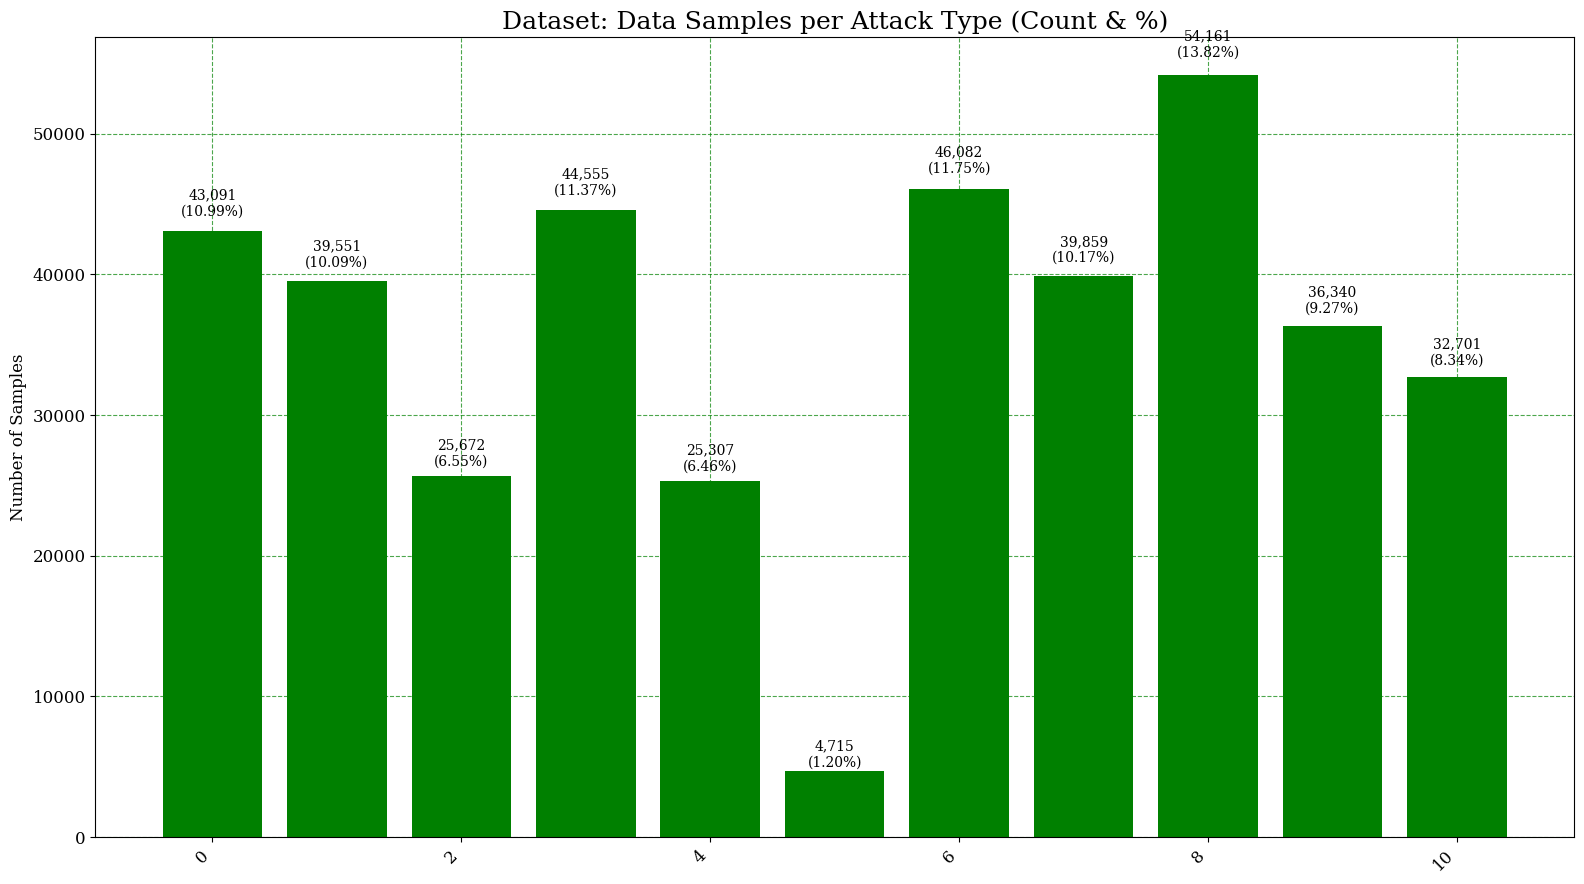

In [70]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [71]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

if len(categorical_cols) > 0 and not df[categorical_cols].mode().empty:
    df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
else:
    print("Nothing to fill in categorical columns.")

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled



Columns with Missing Values:
 Series([], dtype: int64)
Nothing to fill in categorical columns.
Missing values after filling:
 0


In [72]:
# Print the names of the features (columns)
print(df.columns)

Index(['Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       

## **Data Preprocessing**

In [73]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ১. ইনফিনিটি এবং গারবেজ ভ্যালু ক্লিন করা
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)
df.dropna(inplace=True)

# ২. Numerical কলাম আলাদা করা (Label বাদ দিয়ে)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.difference(['Label'])

# ৩. ফিচার স্কেলিং (শুধু Numerical ফিচারে)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# ৪. Categorical কলাম আলাদা করা (Label বাদ দিয়ে)
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])

# ৫. Categorical এনকোডিং (সব কলাম স্ট্রিং নিশ্চিত করে)
df[cat_cols] = df[cat_cols].astype(str)
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)



print("Preprocessing Success!")
print(df['Label'].value_counts()) # চেক করুন শুধু ০ এবং ১ আছে কি না


Preprocessing Success!
Label
8     54161
6     46082
3     44555
0     43091
7     39859
1     39551
9     36340
10    32701
2     25672
4     25307
5      4715
Name: count, dtype: int64


In [74]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-0.358896,-0.515637,-0.479042,-0.032246,-0.008793,0.011525,-0.034386,1.026506,-0.222340,0.910006,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
1,-0.358896,-0.515637,-0.485900,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
2,-0.358896,-0.515637,-0.485911,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
3,-0.358896,-0.515637,-0.484230,-0.181792,-0.095267,-0.051344,-0.076005,-0.353481,0.298340,-0.228280,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
4,-0.358896,-0.515637,-0.477782,-0.032246,-0.021147,0.025783,-0.073212,0.907722,-0.222340,1.213123,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,-0.384353,1.874255,-0.484792,-0.181792,-0.095267,-0.050322,-0.074195,-0.323785,0.583875,-0.097825,...,0.002826,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392030,-0.379784,1.874255,-0.482212,-0.181792,-0.095267,-0.050322,-0.075569,-0.323785,0.583875,-0.097825,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392031,-0.384353,1.874255,-0.483113,-0.181792,-0.095267,-0.050863,-0.075114,-0.339507,0.432709,-0.166890,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392032,-0.384353,1.874255,-0.484786,-0.181792,-0.095267,-0.051044,-0.074613,-0.344747,0.382321,-0.189911,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10


## **After Processing**

In [75]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


In [76]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()

# **Binary Class (Anomaly) Classification**

In [77]:
# বাইনারি ক্লাসিফিকেশনের জন্য লেবেল রূপান্তর (যদি ০ Benign হয়)
# এটি করলে আপনার ১১টি ক্লাস ০ এবং ১ এ চলে আসবে
df1['Label'] = df1['Label'].apply(lambda x: 0 if x == 0 else 1)

# Check counts
print(df1['Label'].value_counts())

# Define label and feature columns
X = df1.drop(columns=['Label'])
y = df1['Label']

Label
1    348943
0     43091
Name: count, dtype: int64


In [78]:
X.head()

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.358896,-0.515637,-0.479042,-0.032246,-0.008793,0.011525,-0.034386,1.026506,-0.22234,0.910006,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
1,-0.358896,-0.515637,-0.485900,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.22234,-0.377920,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
2,-0.358896,-0.515637,-0.485911,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.22234,-0.377920,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
3,-0.358896,-0.515637,-0.484230,-0.181792,-0.095267,-0.051344,-0.076005,-0.353481,0.29834,-0.228280,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
4,-0.358896,-0.515637,-0.477782,-0.032246,-0.021147,0.025783,-0.073212,0.907722,-0.22234,1.213123,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464


## **Traing and Test Division**

In [79]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.3,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (274423, 78)
X_test shape:  (117611, 78)
y_train shape: (274423,)
y_test shape:  (117611,)


Feature selection

In [80]:

import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier # Changed from RandomForestClassifier

# ১. লেবেলগুলোকে অবশ্যই পূর্ণসংখ্যা (Integer) হতে হবে
# আপনার লেবেলে যদি -১.৫৪ টাইপ ভ্যালু থাকে, সেগুলোকে ০ এবং ১-এ বদলে নিন
#y_train_int = y_train.astype(int)

# ২. LightGBM মডেল (ইমব্যালেন্স ডাটা হ্যান্ডেল করার জন্য)
lgbm_selector = LGBMClassifier(
    n_estimators=100, # Number of boosting rounds
    random_state=42,  # For reproducibility
    class_weight='balanced' # Handles imbalanced classes
)

# ৩. ট্রেইন করা
lgbm_selector.fit(X_train, y_train)

# ৪. এখন ইম্পর্ট্যান্স চেক করুন
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_selector.feature_importances_ # Using LGBM feature importances
}).sort_values(by='Importance', ascending=False)

# ৫. সেরা ৪০টি ফিচারের নাম নেওয়া
top_25_features = importance_df.head(10)['Feature'].tolist()

print("Top 10 Features (LightGBM) for Binary Classification:")
print(importance_df.head(10))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.447392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14114
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Top 10 Features (LightGBM) for Binary Classification:
                    Feature  Importance
67  Init_Win_bytes_backward         305
66   Init_Win_bytes_forward         293
20             Flow IAT Min         153
42        Packet Length Std         121
25              Fwd IAT Min         114
19             Flow IAT Max         100
0          Destination Port          92
12    Bwd Packet Length Min          91
2          

/tmp/ipykernel_6205/1224220588.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


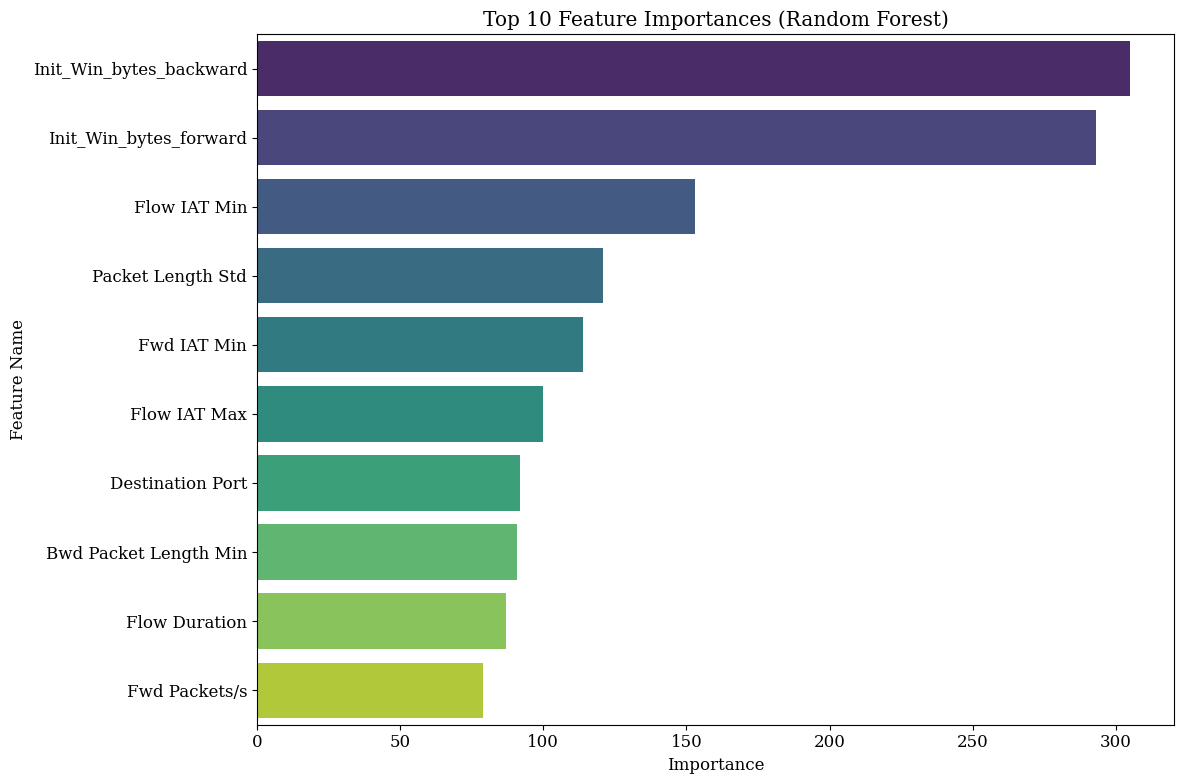

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.8766
Precision: 0.8782
Recall:    0.8766
F1 Score:  0.8774


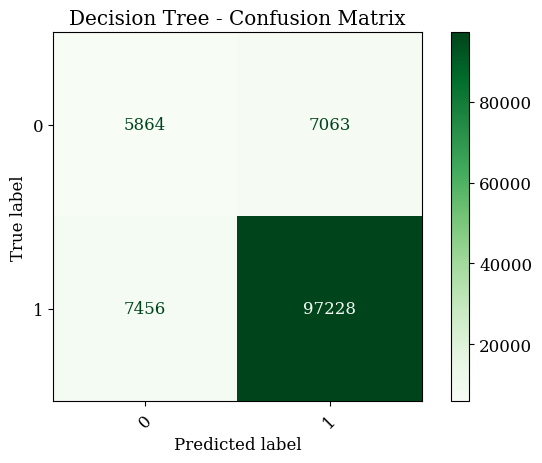

Classification Report:
              precision    recall  f1-score   support

           0    0.44024   0.45362   0.44683     12927
           1    0.93228   0.92878   0.93052    104684

    accuracy                        0.87655    117611
   macro avg    0.68626   0.69120   0.68868    117611
weighted avg    0.87819   0.87655   0.87736    117611



In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
X_train_sel = X_train[top_25_features]
X_test_sel = X_test[top_25_features]


# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.90223
Precision: 0.89083
Recall:    0.90223
F1 Score:  0.89463


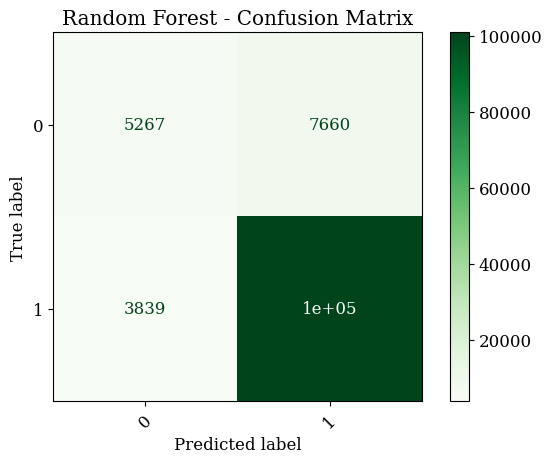

Classification Report:
              precision    recall  f1-score   support

           0    0.57841   0.40744   0.47810     12927
           1    0.92940   0.96333   0.94606    104684

    accuracy                        0.90223    117611
   macro avg    0.75391   0.68538   0.71208    117611
weighted avg    0.89083   0.90223   0.89463    117611



In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.89164
Precision: 0.87383
Recall:    0.89164
F1 Score:  0.87947


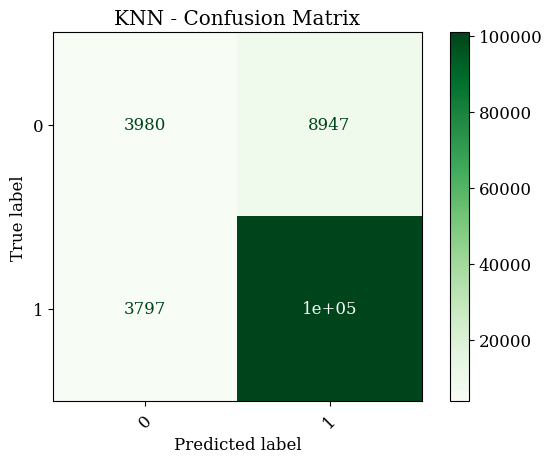

Classification Report:
              precision    recall  f1-score   support

           0    0.51177   0.30788   0.38447     12927
           1    0.91854   0.96373   0.94059    104684

    accuracy                        0.89164    117611
   macro avg    0.71515   0.63581   0.66253    117611
weighted avg    0.87383   0.89164   0.87947    117611



In [84]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=3)  # You can tune n_neighbors
knn_model.fit(X_train_sel, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test_sel)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Training Voting Classifier...
Voting Classifier training complete.

Voting Classifier Accuracy:  0.91285
Voting Classifier Precision: 0.90122
Voting Classifier Recall:    0.91285
Voting Classifier F1 Score:  0.89776


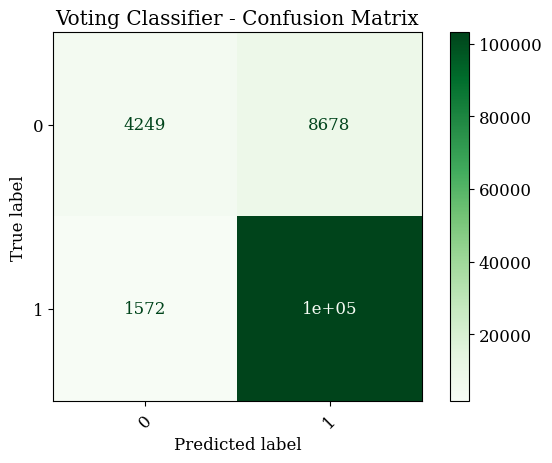

Voting Classifier Classification Report:
              precision    recall  f1-score   support

           0    0.72994   0.32869   0.45328     12927
           1    0.92237   0.98498   0.95265    104684

    accuracy                        0.91285    117611
   macro avg    0.82616   0.65684   0.70296    117611
weighted avg    0.90122   0.91285   0.89776    117611



In [85]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Import LightGBM and XGBoost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Re-initialize individual classifiers for the VotingClassifier
# (using the best parameters found in previous cells if applicable,
# or default parameters if not explicitly optimized)

# dt_model = DecisionTreeClassifier(random_state=42) # Removed as requested
rf_model = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
# knn_model = KNeighborsClassifier(n_neighbors=3) # Removed as requested

lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)

# Define X_train_sel and X_test_sel from the top_25_features
X_train_sel = X_train[top_25_features]
X_test_sel = X_test[top_25_features]

# Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        # ('dt', dt_model),
        ('rf', rf_model),
        # ('knn', knn_model)
        ('lgbm', lgbm_model),
        ('xgb', xgb_model)
    ],
    voting='soft',  # 'hard' for majority vote, 'soft' for weighted average of probabilities
    n_jobs=-1
)

print("Training Voting Classifier...")
# Train the Voting Classifier
voting_clf.fit(X_train_sel, y_train)
print("Voting Classifier training complete.")

# Predict on Test Set
y_pred_voting = voting_clf.predict(X_test_sel)

# Evaluation Metrics
accuracy_voting = accuracy_score(y_test, y_pred_voting)
precision_voting = precision_score(y_test, y_pred_voting, average='weighted', zero_division=0)
recall_voting = recall_score(y_test, y_pred_voting, average='weighted', zero_division=0)
f1_voting = f1_score(y_test, y_pred_voting, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nVoting Classifier Accuracy:  {accuracy_voting:.5f}")
print(f"Voting Classifier Precision: {precision_voting:.5f}")
print(f"Voting Classifier Recall:    {recall_voting:.5f}")
print(f"Voting Classifier F1 Score:  {f1_voting:.5f}")

# Confusion Matrix
cm_voting = confusion_matrix(y_test, y_pred_voting)
ConfusionMatrixDisplay(cm_voting, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_voting, zero_division=0, digits=5))


# **Multiclass Classification**

In [62]:
# Define label and feature columns
X = df2.drop(columns=['Label'])
y = df2['Label']

## **Traing and Test Division**

In [86]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 78)
X_test shape:  (78407, 78)
y_train shape: (313627,)
y_test shape:  (78407,)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 279154, number of negative: 34473
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.250510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14112
[LightGBM] [Info] Number of data points in the train set: 313627, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Top 10 Features for Multiclassification (LightGBM):
                    Feature  Importance
66   Init_Win_bytes_forward         293
67  Init_Win_bytes_backward         271
20             Flow IAT Min         141
25              Fwd IAT Min         128
42        Packet Length Std         125
19             Flow IAT Max         100
0          Destination Port          96
40        Max Packet Length          94
12    Bwd P

/tmp/ipykernel_6205/1523890530.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_multi.head(10), palette='viridis')


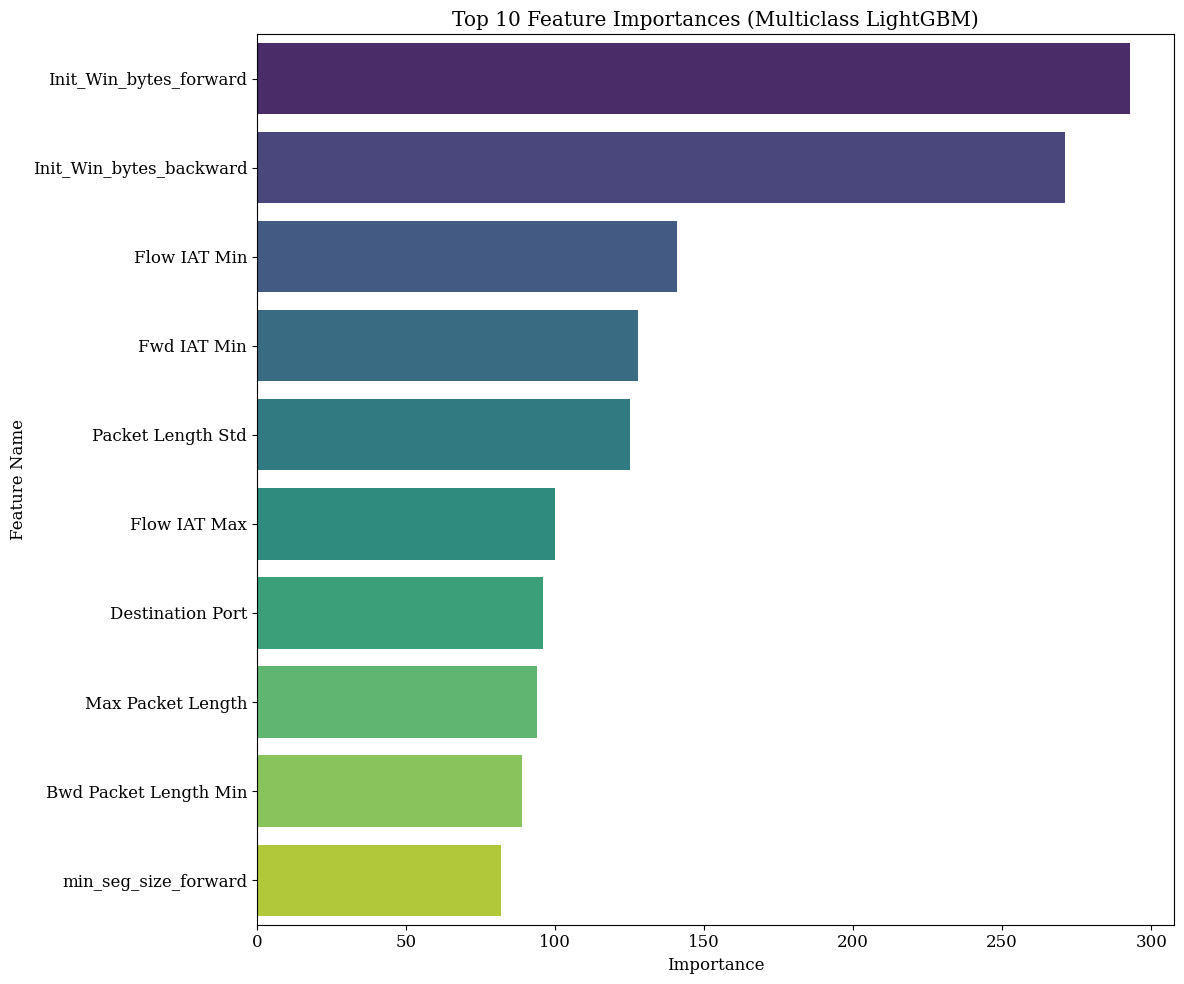

In [87]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier # Changed from RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LightGBM model for feature importance (changed from Random Forest)
lgbm_selector_multi = LGBMClassifier(
    n_estimators=100, # Number of boosting rounds
    random_state=42,  # For reproducibility
    class_weight='balanced' # Handles imbalanced classes, important for multiclass
)

# 2. Train the model on the multiclass training data
lgbm_selector_multi.fit(X_train, y_train)

# 3. Get feature importances
importance_df_multi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_selector_multi.feature_importances_ # Using LGBM feature importances
}).sort_values(by='Importance', ascending=False)

# 4. Select the top 10 features (adjust as needed)
top_10_features_multi = importance_df_multi.head(10)['Feature'].tolist()

print("Top 10 Features for Multiclassification (LightGBM):")
print(importance_df_multi.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df_multi.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Multiclass LightGBM)') # Updated title
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

X_train_sel_multi = X_train[top_10_features_multi]
X_test_sel_multi = X_test[top_10_features_multi]

## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.8829
Precision: 0.8845
Recall:    0.8829
F1 Score:  0.8837


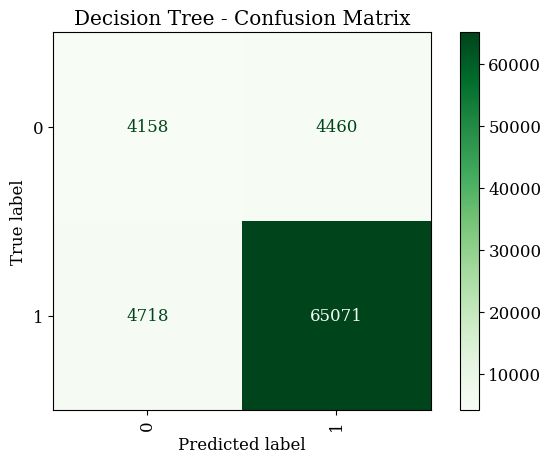

Classification Report:
              precision    recall  f1-score   support

           0    0.46845   0.48248   0.47536      8618
           1    0.93586   0.93240   0.93412     69789

    accuracy                        0.88294     78407
   macro avg    0.70216   0.70744   0.70474     78407
weighted avg    0.88448   0.88294   0.88370     78407



In [88]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sel_multi, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_sel_multi)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Voting

Training Multiclass Voting Classifier...
Multiclass Voting Classifier training complete.

Multiclass Voting Classifier Accuracy:  0.91650
Multiclass Voting Classifier Precision: 0.90773
Multiclass Voting Classifier Recall:    0.91650
Multiclass Voting Classifier F1 Score:  0.90096


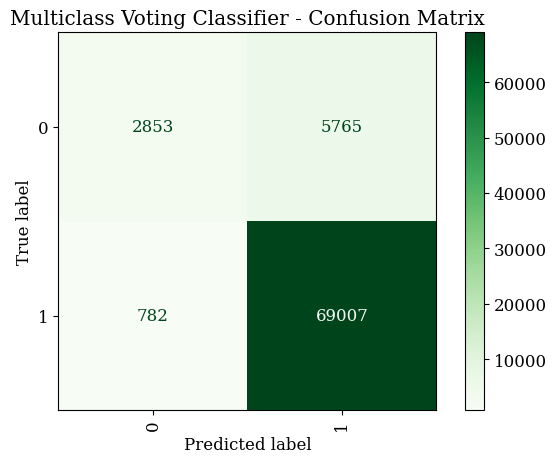

Multiclass Voting Classifier Classification Report:
              precision    recall  f1-score   support

           0    0.78487   0.33105   0.46568      8618
           1    0.92290   0.98879   0.95471     69789

    accuracy                        0.91650     78407
   macro avg    0.85388   0.65992   0.71020     78407
weighted avg    0.90773   0.91650   0.90096     78407



In [89]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Import LightGBM and XGBoost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Re-initialize individual classifiers for the VotingClassifier
# Using parameters from previously trained models or sensible defaults

# Removed Decision Tree and KNN, added LightGBM and XGBoost
# dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Adjust n_estimators as needed
# knn_model = KNeighborsClassifier(n_neighbors=5) # Using n_neighbors=5 as in previous KNN multiclassification

lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)

# Create the Voting Classifier
voting_clf_multi = VotingClassifier(
    estimators=[
        # ('dt', dt_model),
        ('rf', rf_model),
        # ('knn', knn_model)
        ('lgbm', lgbm_model),
        ('xgb', xgb_model)
    ],
    voting='soft',  # 'soft' for weighted average of probabilities (if supported by base estimators)
    n_jobs=-1
    # Weights can be adjusted based on individual model performance
    # weights=[1, 1, 1] # Example weights if you want to assign them
)

print("Training Multiclass Voting Classifier...")
# Train the Voting Classifier on the selected features
voting_clf_multi.fit(X_train_sel_multi, y_train)
print("Multiclass Voting Classifier training complete.")

# Predict on Test Set using selected features
y_pred_voting_multi = voting_clf_multi.predict(X_test_sel_multi)

# Evaluation Metrics
accuracy_voting_multi = accuracy_score(y_test, y_pred_voting_multi)
precision_voting_multi = precision_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)
recall_voting_multi = recall_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)
f1_voting_multi = f1_score(y_test, y_pred_voting_multi, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nMulticlass Voting Classifier Accuracy:  {accuracy_voting_multi:.5f}")
print(f"Multiclass Voting Classifier Precision: {precision_voting_multi:.5f}")
print(f"Multiclass Voting Classifier Recall:    {recall_voting_multi:.5f}")
print(f"Multiclass Voting Classifier F1 Score:  {f1_voting_multi:.5f}")

# Confusion Matrix
cm_voting_multi = confusion_matrix(y_test, y_pred_voting_multi)
ConfusionMatrixDisplay(cm_voting_multi, display_labels=voting_clf_multi.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Multiclass Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Multiclass Voting Classifier Classification Report:")
print(classification_report(y_test, y_pred_voting_multi, zero_division=0, digits=5))


## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.90695
Precision: 0.89678
Recall:    0.90695
F1 Score:  0.90004


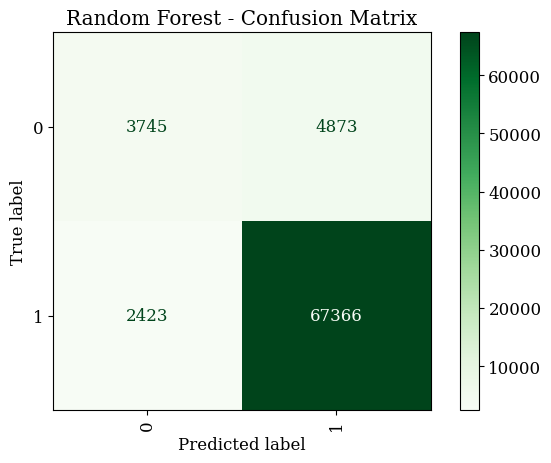

Classification Report:
              precision    recall  f1-score   support

           0    0.60717   0.43456   0.50656      8618
           1    0.93254   0.96528   0.94863     69789

    accuracy                        0.90695     78407
   macro avg    0.76985   0.69992   0.72760     78407
weighted avg    0.89678   0.90695   0.90004     78407



In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 10, random_state=42)
rf_model.fit(X_train_sel_multi, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test_sel_multi)
y_proba = rf_model.predict_proba(X_test_sel_multi) # Corrected X_test_mul to X_test_sel_multi

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.90173
Precision: 0.88420
Recall:    0.90173
F1 Score:  0.88611


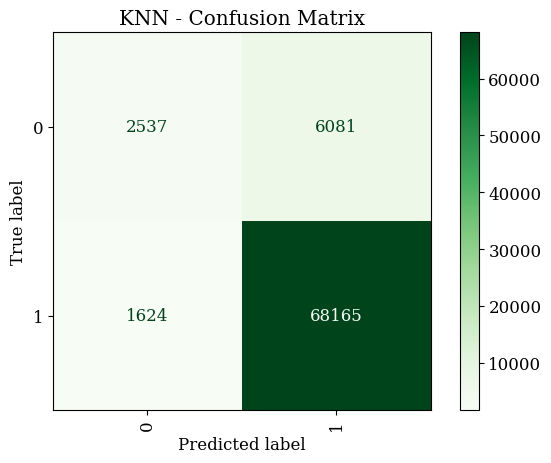

Classification Report:
              precision    recall  f1-score   support

           0    0.60971   0.29438   0.39706      8618
           1    0.91810   0.97673   0.94651     69789

    accuracy                        0.90173     78407
   macro avg    0.76390   0.63556   0.67178     78407
weighted avg    0.88420   0.90173   0.88611     78407



In [91]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train_sel_multi, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test_sel_multi)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Modified Confusion Matrix**

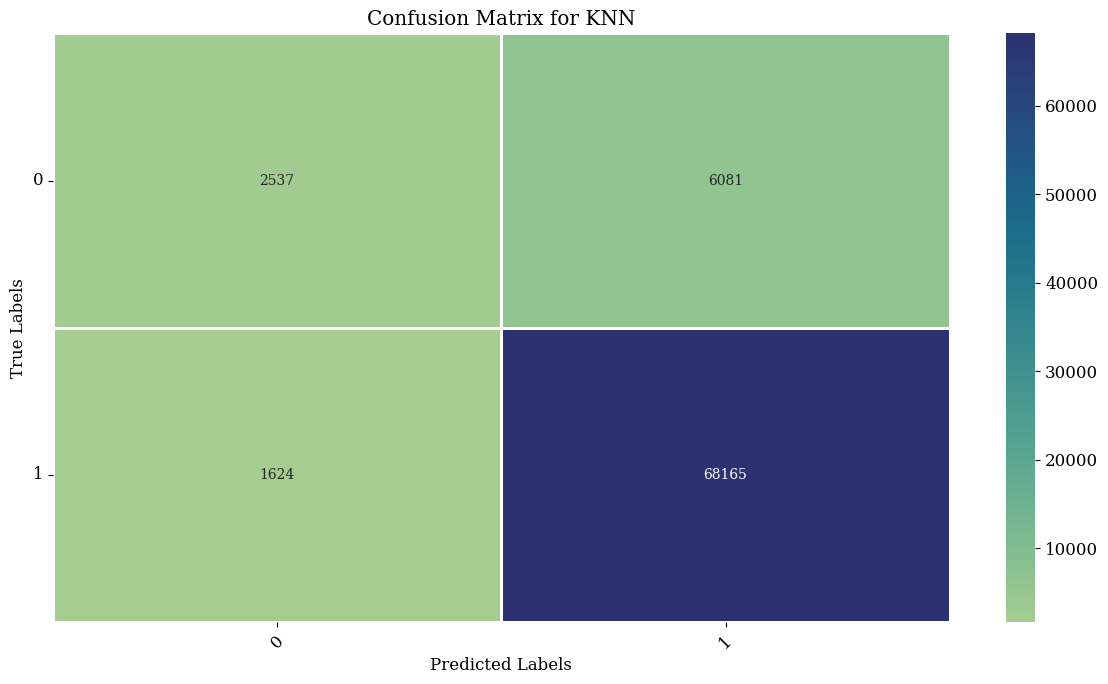

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**